In [1]:
!mamba install fastcore=1.5.29 

warning  libmamba 'repo.anaconda.com', a commercial channel hosted by Anaconda.com, is used.
    
warning  libmamba Please make sure you understand Anaconda Terms of Services.
    
warning  libmamba See: https://legal.anaconda.com/policies/en/
[+] 0.0s
[+] 0.1s
pkgs/main/osx-64 ---------------------------   0.0 B /  ??.?MB @  ??.?MB/s  0.1s[+] 0.2s
pkgs/main/osx-64 ---------------------------   0.0 B /  ??.?MB @  ??.?MB/s  0.2s[+] 0.3s
pkgs/main/osx-64 ---------------------------   0.0 B /  ??.?MB @  ??.?MB/s  0.3s
Pinned packages:

  - python=3.10


Transaction

  Prefix: /Users/zoe/.local/share/mamba/envs/tapas-upgrade

  All requested packages already installed


Transaction starting

Transaction finished



In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["SYNTHCITY_DEVICE"] = "cpu"

import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from tapas.generators.generator import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from tools.tapas.tapas_data_processors import AdultDataProcessor
import random




from tapas.generators.generator import ReprosynGenerator
from reprosyn.methods import DS_PRIVBAYES
from reprosyn.methods import DS_BAYNET
from tools.tapas.generators import SynthcityGenerator
from tools.tapas.generators import BenchmarkGenerator

/Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
!pip install tf_keras

  Using cached tf_keras-2.19.0-py3-none-any.whl.metadata (1.8 kB)
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
  Using cached tf_keras-2.18.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached tf_keras-2.17.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached tf_keras-2.16.0-py3-none-any.whl.metadata (1.6 kB)
Using cached tf_keras-2.16.0-py3-none-any.whl (1.7 MB)


In [10]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
data = data.sample(frac = 0.05)  #downsample the data 
print(len(data.data))
ind = [int(random.random() * len(data.data))]

2261


In [11]:
my_dataset = data

In [12]:
benchmark_gen = BenchmarkGenerator(ReprosynGenerator, method_kwargs = {
    'reprosyn_class': DS_PRIVBAYES},
    param_kwargs = {'epsilon': 1.0
})

benchmark_gen.fit(my_dataset)
synthetic_data = benchmark_gen.generate(1000)
print(benchmark_gen.parameters)

{'epsilon': 1.0}


In [13]:
benchmark_gen.label

"<class 'reprosyn.methods.data_synthesiser.wrapper.DS_PRIVBAYES'>"

In [14]:
benchmark_gen.get_filename_label()

"<class 'reprosyn.methods.data_synthesiser.wrapper.DS_PRIVBAYES'>_epsilon=1.0"

In [16]:
benchmark_gen = BenchmarkGenerator(SynthcityGenerator, {'plugin_name': "ddpm"} , {})





benchmark_gen.fit(my_dataset)
synthetic_data = benchmark_gen.generate(1000)


[2025-05-03T17:24:35.908167+0100][27131][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
Epoch: 100%|█████████████████████| 1000/1000 [02:59<00:00,  5.56it/s, loss=1.43]


AttributeError: 'BenchmarkGenerator' object has no attribute 'get_hyperparameters'

In [19]:
print(benchmark_gen.get_filename_label())

ddpm_


In [ ]:
synthetic_data.data

2261
estimating categorical probs
estimating approx kdes(histogram)
[0.5876106194690266]
Generator : ctgan
Generate datasets


[2025-04-21T18:20:46.598579+0200][50292][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-04-21T18:20:46.599456+0200][50292][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-04-21T18:20:46.600086+0200][50292][CRITICAL] module plugin_great load failed
[2025-04-21T18:20:46.601098+0200][50292][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
 32%|████████████▉                           | 649/2000 [01:28<03:03,  7.37it/s]
[2025-04-21T18:22:16.490463+0200][50292][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-04-21T18:22:16.491384+0200][50292][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-04-21T18:22:16.492049+0200][50292][CRITICAL] module plugin_great load failed
[2025-04-21T

[2025-04-21T19:32:52.126588+0200][50292][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-04-21T19:32:52.127753+0200][50292][CRITICAL] module plugin_great load failed
[2025-04-21T19:32:52.129132+0200][50292][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
 40%|███████████████▉                        | 799/2000 [01:55<02:53,  6.93it/s]
[2025-04-21T19:34:48.602357+0200][50292][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-04-21T19:34:48.603178+0200][50292][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-04-21T19:34:48.603888+0200][50292][CRITICAL] module plugin_great load failed
[2025-04-21T19:34:48.604937+0200][50292][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synt

COMPLEXITY:  2
COMPLEXITY:  10
COMPLEXITY:  20


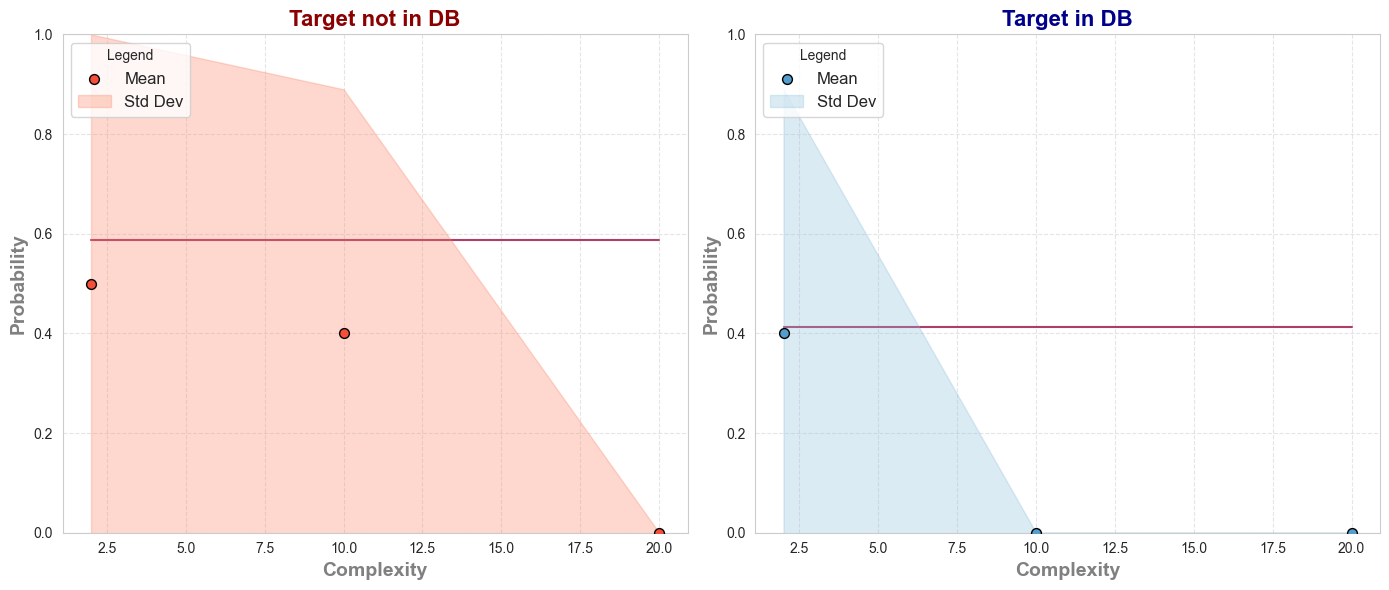

In [7]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
data = data.sample(frac = 0.05)  #downsample the data 
print(len(data.data))
ind = [int(random.random() * len(data.data))]

target_record = data.get_records(ind)
data.drop_records(ind, in_place=True)

attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2000))

generator = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)
gen = ReprosynGenerator(DS_BAYNET, label="BayNet")
syn_tab = SynthcityGenerator("ddpm", label="TabDDPM", 
                    lr=0.00013067363723152697,
                    batch_size=2048,
                    n_iter=1000,
                    num_timesteps=100,
                    model_params={
                        'n_layers_hidden': 4,
                        'n_units_hidden':128,
                        'dropout': 0.000871018582934785
                    })
syn_tab2 = SynthcityGenerator("ctgan", label="ctgan")
list = ['adsgan',
 'dpgan',
 'fflows', #timeseries 
 'radialgan', #domain adaptation
 'survival_ctgan',#timeseries
 'dummy_sampler', #raw?
 'tvae',
 'bayesian_network',
 'uniform_sampler',
 'survival_nflow', #timeseries
 'pategan',
 'image_adsgan', #images
 'ddpm', 
 'image_cgan', #images
 'rtvae',
 'nflow',
 'timegan', #timeseries
 'aim',
 'survae',#timeseries
 'decaf',
 'survival_gan', #timeseries
 'privbayes',
 'timevae', #timeseries
 'ctgan', 
 'marginal_distributions',
 'arf']


syn3 = SynthcityGenerator("adsgan", label="adsgan") #works    ->>>< becomes SynthcityGenerator, 
syn4 = SynthcityGenerator("dpgan", label="dpgan") #works 
syn8 = SynthcityGenerator("tvae", label="tvae") #works 
syn9 = SynthcityGenerator("bayesian_network", label="bayesian_network") #works 
syn10 = SynthcityGenerator("uniform_sampler", label="uniform_sampler") #works
syn11 = SynthcityGenerator("dummy_sampler", label = "dummy_sampler") #works
syn12 = SynthcityGenerator(
    "pategan",
    label="pategan",
    n_iter=10,
    device="cpu",  # this should override GPU usage
    batch_size=64,  # reduce memory pressure
    random_state=0
) # crashes  -> try pategan from reprosyn........!!!!!!!!!!!!!!!!!
syn13 = SynthcityGenerator("rtvae", label= "rtvae") #works
syn14 = SynthcityGenerator("nflow", "nflow") #works 
syn15 = SynthcityGenerator("aim", "aim") #works? but takes foreveeeeeer
syn16 = SynthcityGenerator("decaf", "decaf") #runs, but not sure if it works... look at generated datasets, and 
syn17 = SynthcityGenerator("privbayes", "privbayes") #works, but takes forever (much longer than tapas) (weird results)
syn18 = SynthcityGenerator("ctgan", "ctgan") #wotks but weird results? 




pipeline = BenchmarkPipeline(data, attack, [syn18], target_record=target_record)
pipeline.run([2,10,20], 10, 2)

In [8]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
data = data.sample(frac = 0.1)  #downsample the data 
print(len(data.data))

4522


In [ ]:
syn18 = SynthcityGenerator("ctgan", "ctgan")